# SDM in Python

Some features based on https://github.com/daniel-furman/eco-distribution-mapping/blob/main/Python-sdm.ipynb

### Generate Pseudo-Absence Data
Absence data must be generated for these classifiers, and different quantities must be generated for types of classifiers, based on Barbet-Massin et al., 2012.

### Making subdirectories
inputs - files input for processing   
outputs - results from processing

In [13]:
import os
# os.mkdir("inputs", ex)
# os.mkdir("outputs")
import subprocess
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from pygam import GAM, s, f
from sklearn.tree import DecisionTreeClassifier
# out of all the glms, we choose the poisson - it does not have negative values, and varying variance???
# also we are looking for a scale of values up to 1000...
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pyimpute import impute
from sklearn import model_selection
from elapid import MaxentModel

Run the subprocess, R code to generate pseudo absences. Will be customized depending on the models

In [16]:
command = ["C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe",'pseudo_absence.R', 
           'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', "2", "northerncorn"]
subprocess.run(command, check = True)

CompletedProcess(args=['C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe', 'pseudo_absence.R', 'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', '2', 'northerncorn'], returncode=0)

### Converting shapefiles (.shp) to geopandas dataframe

In [17]:
import geopandas as gpd
import shutil
import glob

# for f in sorted(glob.glob('data/ncr*')):
#     shutil.copy(f, 'inputs/')

ncr_gdf = gpd.GeoDataFrame.from_file('data/ncr.shp')
ncr_gdf.sample(5)

,CLASS,geometry
1644,0.0,POINT (-86.70338 30.53285)
1745,0.0,POINT (-101.36627 37.64246)
1574,0.0,POINT (-89.65055 30.85269)
1905,0.0,POINT (-116.72462 43.84117)
1979,1.0,POINT (-89.65781 42.29142)


Checking duplicates and NA values. Coordinate reference system should ideally be epsg: 4326

In [18]:
print("Number of duplicates: ", ncr_gdf.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf.crs))
print("{} observations with {} columns".format(*ncr_gdf.shape))

Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
2122 observations with 2 columns


Mapping the species presences (pa == 1)

<Axes: >

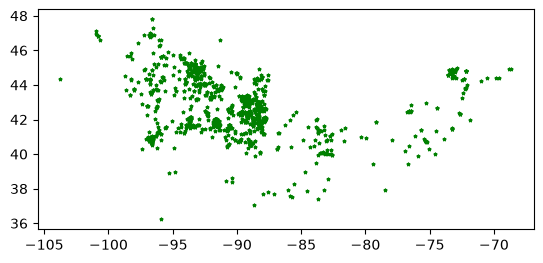

In [19]:
ncr_gdf[ncr_gdf.CLASS == 1].plot(marker='*', color='green', markersize=5)

Mapping the species absences (pa == 0)

<Axes: >

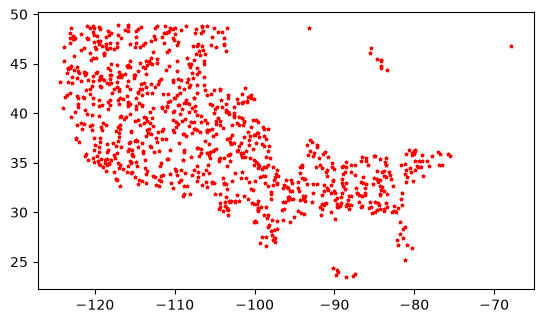

In [20]:
ncr_gdf[ncr_gdf.CLASS == 0].plot(marker='*', color='red', markersize=5)

### Classifier Training

In [21]:
# TO MOVE FILES INTO INPUT
# for f in sorted(glob.glob('worldclim/wc2.1_2.5m_bio_*.tif')):
#     shutil.copy(f,'inputs/')

ras_feats = sorted(glob.glob(
    'worldclim/wc2.1_2.5m_bio_*.tif'))

print('There are ', len(ras_feats), ' raster features.')


There are  7  raster features.


In [22]:
print(ras_feats)

['worldclim\\wc2.1_2.5m_bio_13.tif', 'worldclim\\wc2.1_2.5m_bio_14.tif', 'worldclim\\wc2.1_2.5m_bio_15.tif', 'worldclim\\wc2.1_2.5m_bio_2.tif', 'worldclim\\wc2.1_2.5m_bio_4.tif', 'worldclim\\wc2.1_2.5m_bio_5.tif', 'worldclim\\wc2.1_2.5m_bio_6.tif']


Generate raster maps of suitability. Also separate test sets from the rest for cross validation

In [ ]:
from pyimpute import load_training_vector
from pyimpute import load_targets

train_xs, train_ys = load_training_vector(ncr_gdf, ras_feats, response_field='CLASS')
train_x, test_x, train_y, test_y = model_selection.train_test_split(train_xs, train_ys, test_size=0.25, random_state=42)
target_xs, raster_info = load_targets(ras_feats)
# train_xs.shape, train_ys.shape
train_x.shape, test_x.shape, train_y.shape, test_y.shape

RasterioIOError: CLASS: No such file or directory

In [26]:
print(train_xs)
print(train_ys)

[[114.0 26.0 42.88031005859375 ... 1114.2421875 28.40399932861328
  -13.596000671386719]
 [104.0 22.0 47.06314468383789 ... 1148.0421142578125 28.308000564575195
  -14.699999809265137]
 [25.0 7.0 25.64087677001953 ... 825.2771606445312 35.7400016784668
  -3.5320000648498535]
 ...
 [72.0 10.0 70.56594848632812 ... 800.6510620117188 34.448001861572266
  -4.107999801635742]
 [91.0 33.0 28.597597122192383 ... 1029.2808837890625 26.59200096130371
  -12.51200008392334]
 [101.0 3.0 82.43087768554688 ... 681.4707641601562 28.36400032043457
  -4.196000099182129]]
[1. 1. 0. ... 0. 1. 0.]


Classifier implementation

In [25]:
from sklearn.utils.class_weight import compute_sample_weight
CLASS_MAP = {
    'rf': (RandomForestClassifier()),
    # 'et': (ExtraTreesClassifier()),
    'lda': (LinearDiscriminantAnalysis()),
    'dtc': (DecisionTreeClassifier()),
    'glm': (LogisticRegression()),
    'xgb': (XGBClassifier()),
    'lgbm': (LGBMClassifier()),
    # 'maxent': (MaxentModel())
}

ALT_MAP = {
    'gam': (GAM()),
    'mars': (make_pipeline(SplineTransformer(degree=1, n_knots=10, include_bias=False), LinearRegression()))
}

sample_weights = compute_sample_weight(class_weight='balanced', y=train_y)

for name, (model) in CLASS_MAP.items():
    # cross validation for accuracy scores (displayed as a percentage)
    k = 4 # k-fold
    kf = model_selection.KFold(n_splits=k, shuffle=True, random_state=42)
    accuracy_scores = model_selection.cross_val_score(model, train_x, train_y, cv=kf, scoring='accuracy')
    print(name + " %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, accuracy_scores.mean() * 100, accuracy_scores.std() * 200))
    
    # spatial prediction
    model.fit(train_x, train_y)
    # os.mkdir('outputs/' + name + '-images')
    score = model.score(test_x, test_y)
    print(name + " score: %f" % (score))
    impute(target_xs, model, raster_info, outdir='outputs/' + name + '-images',
           class_prob=True, certainty=True)

rf 4-fold Cross Validation Accuracy: 99.12 (+/- 0.83)
rf score: 0.990584


KeyboardInterrupt: 

Averaging the outputs of the models, and plotting it onto a map

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:11: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
C:\U

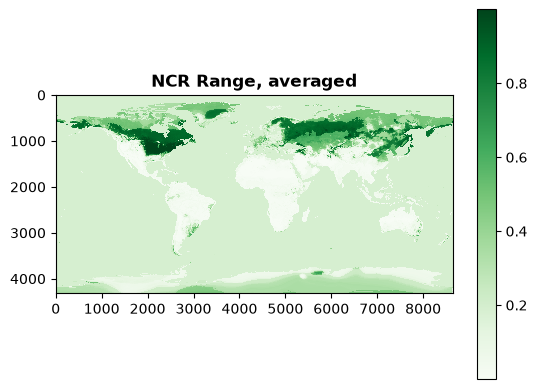

In [ ]:
from pylab import plt
# define spatial plotter
def plotit(x, title, cmap="Blues"):
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontweight = 'bold')

import rasterio
distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
distr_lgbm =  rasterio.open("outputs/lgbm-images/probability_1.0.tif").read(1)
distr_averaged = (distr_rf + distr_et + distr_xgb + distr_lgbm)/4  

plotit(distr_averaged, "NCR Range, averaged", cmap="Greens")